In [26]:
import pysam
import collections
from Bio import SeqIO
import sys

def get_sequence_lengths(fasta_file):
    for record in SeqIO.parse(fasta_file, "fasta"):
        return len(record.seq)

def count_mutations_per_position(sam_file, fasta_file):
    mutation_counts = collections.Counter()
    read_per_position = {}
    length = get_sequence_lengths(fasta_file)
    
    for pos in range(0, length):
        # Position in list corresponds to base A, T, G, C
        read_per_position[pos] = [0, 0, 0, 0]
    
    # Parse the reference sequence
    reference_sequence = ""
    for record in SeqIO.parse(fasta_file, "fasta"):
        reference_sequence = str(record.seq)
        break
    
    # Open the SAM file
    with pysam.AlignmentFile(sam_file, "r") as samfile:
        print_counter = 0
        for read in samfile:
            if not read.is_unmapped:
                if read.mapping_quality>=30:
                    read_seq = read.query_sequence
                    read_pos = read.reference_start
                    if type(read_seq) != type('str'):
                        print("continue")
                        continue
                    
                    # Iterate over the aligned portion of the read
                    adjuster = 0
                    for read_idx, ref_idx in enumerate(read.get_reference_positions(full_length=True)):
                        if ref_idx is None:
                            continue
                        read_base = read_seq[(read_idx)]

                        # Increment the count for the respective base
                        if read_base == 'A':
                            read_per_position[ref_idx][0] += 1
                        elif read_base == 'T':
                            read_per_position[ref_idx][1] += 1
                        elif read_base == 'G':
                            read_per_position[ref_idx][2] += 1
                        elif read_base == 'C':
                            read_per_position[ref_idx][3] += 1
                        else:
                            print(ref_idx)
                            break
    
    # Output the counts for each position
    return read_per_position

sam_file = '/Users/benvyshedskiy/Documents/GitHub/minimap2/BCL11A_RNP2_T3.sam'
reference_seq = '/Users/benvyshedskiy/GangBaoPacBioReads/Cliped_BCL11A.fa'
result = count_mutations_per_position(sam_file, reference_seq)

# Print the result in a sorted manner



Read processing information

In [27]:
import plotly.graph_objects as go
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_BCL11A_RNP2_T3.tsv"
fastq_file = "/Users/benvyshedskiy/GangBaoPacBioReads/BCL11A_RNP2_T3.fastq"
initial_reads = sum(1 for _ in SeqIO.parse(fastq_file, "fastq"))
final_count = len(pd.read_csv(tsv_file, sep='\t', header=0))
quantities = [initial_reads, initial_reads, final_count]  # Reads in input, Reads after preprocessing, Reads aligned
labels = ["Reads in Input", "Reads after Preprocessing", "Reads Aligned"]

# Calculate percentages
total_reads = quantities[0]
percentages = [(q / total_reads) * 100 for q in quantities]

# Create the bar chart
fig = go.Figure()

# Add the bars
fig.add_trace(go.Bar(
    x=labels,
    y=quantities,
    text=[f'{percentage:.2f}% ({quantity:,})' for percentage, quantity in zip(percentages, quantities)],  # Add percentage and count on top of the bars
    textposition='outside',
    marker_color='grey',
    showlegend=False
))

# Customize the layout
fig.update_layout(
    title='Alignment statistics',
    xaxis_title='Categories',
    yaxis_title='Number of Reads',
    yaxis=dict(tickformat=',', linecolor='black', linewidth=2),  # Black lines on the y-axis
    xaxis=dict(linecolor='black', linewidth=2),  # Black lines on the x-axis
    margin=dict(l=40, r=40, t=40, b=40),  # Adjust margins if needed
    plot_bgcolor='white'
)

# Show the plot
fig.show()


Create interactive graph of reads per base and show porportion of each base at each position.

In [28]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Assume result is already defined and populated as in your initial script

# Calculate total reads and base proportions
summed_results = {}
base_proportions = {'A': [], 'T': [], 'G': [], 'C': []}

for key in result.keys():
    total_reads = sum(result[key])
    summed_results[key] = total_reads
    if total_reads > 0:
        base_proportions['A'].append(result[key][0] / total_reads)
        base_proportions['T'].append(result[key][1] / total_reads)
        base_proportions['G'].append(result[key][2] / total_reads)
        base_proportions['C'].append(result[key][3] / total_reads)
    else:
        base_proportions['A'].append(0)
        base_proportions['T'].append(0)
        base_proportions['G'].append(0)
        base_proportions['C'].append(0)

# Base colors
base_colors = {'A': '#7fc97f', 'T': '#beaed4', 'G': '#ffff99', 'C': '#fdc086'}

for record in SeqIO.parse(reference_seq, "fasta"):
    reference = record.seq

ref_seq_dictionary = {'A': [], 'T': [], 'G': [], 'C': []}

poscounter =0 
for nt in str(reference):
    ref_seq_dictionary[nt].append(poscounter)
    poscounter +=1

# Create figure
fig = go.Figure()

# Add total reads bar
fig.add_trace(go.Bar(
    x=list(summed_results.keys()), 
    y=list(summed_results.values()), 
    marker_color='black', 
    marker_line_width=0, 
    name='Total Reads'
))

ajustment = []
for i in range(0,len(base_proportions["A"])):
    ajustment.append(0)
maxreads = max(summed_results.values())
# Add base proportion bars
for base in ['A', 'T', 'G', 'C']:
    fig.add_trace(go.Bar(
        x=np.add(list(summed_results.keys()),-0.5), 
        y=[p * maxreads/10 for  p in base_proportions[base]], 
        base=[(-maxreads/10)+adj for adj in ajustment],
        marker_color=base_colors[base], 
        marker_line_width=0, 
        name=f'{base} Proportion',
        width=0.8, 
        offset=0.1,  
    ))
    ajustment=[adj+p * maxreads/10 for adj,p in zip(ajustment,base_proportions[base])]


for base in ['A', 'T', 'G', 'C']:
    fig.add_trace(go.Bar(
        x=np.add(ref_seq_dictionary[base], -0.5),
        y=[maxreads/10 for a in ref_seq_dictionary[base]], 
        base=[(-maxreads/4) for a in ref_seq_dictionary[base]],
        marker_color=base_colors[base], 
        showlegend=False,
        marker_line_width=0, 
        width=0.8, 
        offset=0.1,  
    ))
    
fig.update_layout(
    title='Reads by Position with Base Proportions',
    xaxis_title='Position',
    yaxis_title='Reads',
    barmode='stack',  # Stack bars to show proportions
    dragmode='pan',  # Allows dragging to pan around
    xaxis_rangeslider_visible=True  # Adds a range slider at the bottom
)

# Show the figure
fig.show()



4311
4311


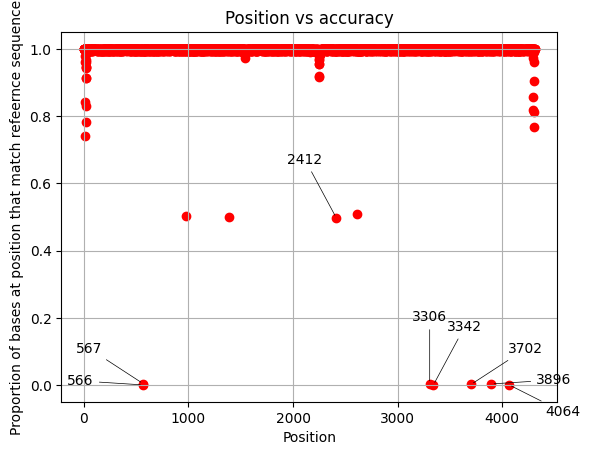

In [36]:
import math
x_vals = []
correct_score = []
for ref_idx in range(0,len(reference)):
    x_vals.append(ref_idx)
    read_base = reference[ref_idx]
    if read_base == 'A':
        correct_score.append(result[ref_idx][0]/sum(result[ref_idx]))
    elif read_base == 'T':
        correct_score.append(result[ref_idx][1]/sum(result[ref_idx]))
    elif read_base == 'G':
        correct_score.append(result[ref_idx][2]/sum(result[ref_idx]))
    elif read_base == 'C':
        correct_score.append(result[ref_idx][3]/sum(result[ref_idx]))
print(len(x_vals))
print(len(correct_score))
import matplotlib.pyplot as plt
plt.scatter(x_vals, correct_score, color='red')
theta = math.pi
for i in range(len(x_vals)):
    if correct_score[i] < 0.5:
        plt.annotate(
            str(x_vals[i]), 
            (x_vals[i], correct_score[i]), 
            textcoords="offset points", 
            xytext=(45*math.cos(theta), 45*math.sin(theta)),  # Offset position
            ha='center',
            arrowprops=dict(
                arrowstyle="-", 
                color='black',
                lw=0.5  # Line width
            )
        )
        theta-=math.pi/6
plt.title('Position vs accuracy')
plt.xlabel('Position')
plt.ylabel('Proportion of bases at position that match refeernce sequence')
plt.grid(True)
plt.show()

Create pie chart from tsv file
6 mutation types long, short: del, ins, wt, complex.
2 pie charts one mod, wt.one in depth

In [6]:
import csv
from collections import Counter
import plotly.graph_objects as go

# Path to your TSV file
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_first10.tsv"

# Initialize a list to store values from the second column
second_column_values = []

# Read the TSV file
with open(tsv_file, mode='r') as file:
    tsv_reader = csv.reader(file, delimiter='\t')
    next(tsv_reader)  # Skip the header row
    for row in tsv_reader:
        # Assuming the second column is at index 1
        value = row[1]
        try:
            # Attempt to convert to float and round if possible
            value = round(float(value), 1)
        except ValueError:
            # If conversion fails, keep the value as is (likely a string like 'WT')
            pass
        second_column_values.append(value)

# Count occurrences of each value
value_counts = Counter(second_column_values)

# Dictionary for the first pie chart (WT vs Others)
wt_count = value_counts.get('WT', 0)
other_count = sum(count for key, count in value_counts.items() if key != 'WT')
wt_vs_other = {'UNMODIFIED': wt_count, 'MODIFIED': other_count}

# Dictionary for the second pie chart (each key in the dictionary)
detailed_counts = dict(value_counts)

# Create the first pie chart (WT vs Other)
fig1 = go.Figure(data=[go.Pie(labels=list(wt_vs_other.keys()), values=list(wt_vs_other.values()))])
fig1.update_layout(title='Proportion of WT vs Other')

fig1.update_traces(
        textposition="outside",
        texttemplate="%{label} %{value} %{percent:.2p}",
)


# Create the second pie chart (detailed counts)
fig2 = go.Figure(data=[go.Pie(labels=list(detailed_counts.keys()), values=list(detailed_counts.values()))])
fig2.update_layout(title='Detailed Counts')

fig2.update_traces(
        textposition="outside",
        texttemplate="%{label} %{value} %{percent:.2p}",
)

# Display the plots
fig1.show()
fig2.show()


Small/Large Insertion pos graph

In [7]:
import re
import pandas as pd
import plotly.graph_objects as go
from Bio import SeqIO

# File paths and reading the data
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_first10.tsv"
reference_seq = '/Users/benvyshedskiy/GangBaoPacBioReads/Cliped_BCL11A.fa'

df = pd.read_csv(tsv_file, sep='\t', header=None, names=['Read_id', 'Classification', 'Mutation_info'])

# Function to parse mutation info
deletion_PerPos_dictionary = {}
insertions_PerPos_dictionary = {}
substitutions_PerPos_dictionary = {}

# Read the reference sequence
for record in SeqIO.parse(reference_seq, "fasta"):
    reference = record.seq

# Initialize dictionaries
for i in range(0, len(reference)): 
    deletion_PerPos_dictionary[i] = 0
    insertions_PerPos_dictionary[i] = 0  
    substitutions_PerPos_dictionary[i] = 0
total_reads = 0
# Extract and count mutations
for idx, row in df.iterrows():
    total_reads+=1
    if row['Classification'] != 'WT':
        parsed = row['Mutation_info'].split(",")
        for mut in parsed:
            if "Del" in str(mut):
                start_pos = int(re.match(r"(\d+)_", mut).group(1))
                end_pos = int(re.search(r"_(\d+)", mut).group(1))
                for position in range(start_pos, end_pos+1):
                    deletion_PerPos_dictionary[position] += 1
            if "Ins" in str(mut):
                start_pos = int(re.match(r"(\d+)_", mut).group(1))
                end_pos = int(re.search(r"_(\d+)", mut).group(1))
                for position in range(start_pos, end_pos+1):
                    insertions_PerPos_dictionary[position] += 1
            if "Sub" in str(mut):
                start_pos = int(re.match(r"(\d+)_", mut).group(1))
                end_pos = int(re.search(r"_(\d+)", mut).group(1))
                for position in range(start_pos, end_pos+1):
                    substitutions_PerPos_dictionary[position] += 1



max_deletions = max(deletion_PerPos_dictionary.values())
max_insertions = max(insertions_PerPos_dictionary.values())
max_sub = max(substitutions_PerPos_dictionary.values())
max_value = max(max_deletions, max_insertions,max_sub)

# Define Y-axis ticks
y_ticks = [i * max_value / 5 for i in range(6)]
y_tick_labels = [f"{(tick / total_reads) * 100:.2f}% ({int(tick)})" for tick in y_ticks]

# Create the plot
fig = go.Figure()

# Add the smooth line for deletions
fig.add_trace(go.Scatter(x=list(deletion_PerPos_dictionary.keys()), 
                         y=list(deletion_PerPos_dictionary.values()), 
                         mode='lines', 
                         line=dict(color='#8172b3'),
                         name='Deletions'))

# Add the smooth line for insertions
fig.add_trace(go.Scatter(x=list(insertions_PerPos_dictionary.keys()), 
                         y=list(insertions_PerPos_dictionary.values()), 
                         mode='lines', 
                         line=dict(color='#c44f51'),  # Different color for insertions
                         name='Insertions'))

# Add Subs
fig.add_trace(go.Scatter(x=list(substitutions_PerPos_dictionary.keys()), 
                         y=list(substitutions_PerPos_dictionary.values()), 
                         mode='lines', 
                         line=dict(color='green'),  # Different color for insertions
                         name='Substitutions'))

# Customize the layout
fig.update_layout(
    title='Deletions and Insertions per Position',
    xaxis_title='Position',
    yaxis_title='Sequence %',
    showlegend=True,
    dragmode='pan',  # Allows dragging to pan around
    xaxis_rangeslider_visible=True  # Adds a range slider at the bottom
)

fig.update_yaxes(tickvals=y_ticks, ticktext=y_tick_labels)

# Show the plot
fig.show()


Insertion average length vs position

In [32]:
import re
import pandas as pd
import plotly.graph_objects as go

# Example data
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_BCL11A_RNP2_T3.tsv"

# Read the data
df = pd.read_csv(tsv_file, sep='\t', header=None, names=['Read_id', 'Classification', 'Mutation_info'])

# Initialize dictionaries
insertions_PerPos_dictionary = {}
insertion_lengths = {}

# Extract and count mutations
for idx, row in df.iterrows():
    if row['Classification'] != 'WT':
        parsed = row['Mutation_info'].split(",")
        for mut in parsed:
            if "Ins" in str(mut):
                start_pos = int(re.match(r"(\d+)_", mut).group(1))
                length = int(re.search(r"Ins_(\d+)", mut).group(1))
                if start_pos not in insertions_PerPos_dictionary:
                    insertions_PerPos_dictionary[start_pos] = 0
                    insertion_lengths[start_pos] = []
                insertions_PerPos_dictionary[start_pos] += 1
                insertion_lengths[start_pos].append(length)

# Calculate average insertion length at each position
average_insertion_lengths = {pos: (sum(lengths) / len(lengths)) if lengths else 0 for pos, lengths in insertion_lengths.items()}

# Create the plot
fig = go.Figure()

# Add the histogram bars for average insertion length
fig.add_trace(go.Bar(
    x=list(average_insertion_lengths.keys()), 
    y=list(average_insertion_lengths.values()), 
    marker=dict(color='red'),
    width=0.5,
    opacity=0.7,
    name='Average Insertion Length',
    hoverinfo='x+y',
    showlegend=False
))

# Add the small red circles on top of the bars
fig.add_trace(go.Scatter(
    x=list(average_insertion_lengths.keys()), 
    y=list(average_insertion_lengths.values()), 
    mode='markers', 
    marker=dict(color='red', size=5),
    name='Average Insertion Length Markers',
    showlegend=False
))

# Customize the layout
fig.update_layout(
    title='Average Insertion Length at Each Position',
    xaxis_title='Position',
    yaxis_title='Average Insertion Length',
    showlegend=True,
    bargap=0.1,  # Adjust the gap between bars
    margin=dict(l=0, r=0, t=50, b=50),  # Adjust margins if needed
    xaxis_rangeslider_visible=True  # Adds a range slider at the bottom
)

# Show the plot
fig.show()


Del average length by pos

In [33]:
import re
import pandas as pd
import plotly.graph_objects as go

# Example data
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_BCL11A_RNP2_T3.tsv"

# Read the data
df = pd.read_csv(tsv_file, sep='\t', header=None, names=['Read_id', 'Classification', 'Mutation_info'])

# Initialize dictionaries
deletions_PerPos_dictionary = {}
deletion_lengths = {}

# Extract and count mutations
for idx, row in df.iterrows():
    if row['Classification'] != 'WT':
        parsed = row['Mutation_info'].split(",")
        for mut in parsed:
            if "Del" in str(mut):
                start_pos = int(re.match(r"(\d+)_", mut).group(1))
                end_pos = int(re.search(r"_(\d+)", mut).group(1))
                length = end_pos - start_pos + 1
                if start_pos not in deletions_PerPos_dictionary:
                    deletions_PerPos_dictionary[start_pos] = 0
                    deletion_lengths[start_pos] = []
                deletions_PerPos_dictionary[start_pos] += 1
                deletion_lengths[start_pos].append(length)

# Calculate average deletion length at each position
average_deletion_lengths = {pos: (sum(lengths) / len(lengths)) if lengths else 0 for pos, lengths in deletion_lengths.items()}

# Create the plot
fig = go.Figure()

# Add the histogram bars for average deletion length
fig.add_trace(go.Bar(
    x=list(average_deletion_lengths.keys()), 
    y=list(average_deletion_lengths.values()), 
    marker=dict(color='blue'),
    width=0.5,
    opacity=0.7,
    name='Average Deletion Length',
    hoverinfo='x+y',
    showlegend=False
))

# Add the small blue circles on top of the bars
fig.add_trace(go.Scatter(
    x=list(average_deletion_lengths.keys()), 
    y=list(average_deletion_lengths.values()), 
    mode='markers', 
    marker=dict(color='blue', size=5),
    name='Average Deletion Length Markers',
    showlegend=False
))

# Customize the layout
fig.update_layout(
    title='Average Deletion Length at Each Position',
    xaxis_title='Position',
    yaxis_title='Average Deletion Length',
    showlegend=True,
    bargap=0.1,  # Adjust the gap between bars
    margin=dict(l=0, r=0, t=50, b=50),  # Adjust margins if needed
    xaxis_rangeslider_visible=True  # Adds a range slider at the bottom

)

# Show the plot
fig.show()


Count of deletions of each size

In [34]:
import re
import pandas as pd
import plotly.graph_objects as go

# Example data
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_BCL11A_RNP2_T3.tsv"

# Read the data
df = pd.read_csv(tsv_file, sep='\t', header=None, names=['Read_id', 'Classification', 'Mutation_info'])

# Initialize dictionaries
deletion_lengths_count = {}

# Extract and count mutations
for idx, row in df.iterrows():
    if row['Classification'] != 'WT':
        parsed = row['Mutation_info'].split(",")
        for mut in parsed:
            if "Del" in str(mut):
                start_pos = int(re.match(r"(\d+)_", mut).group(1))
                end_pos = int(re.search(r"_(\d+)", mut).group(1))
                length = end_pos - start_pos + 1
                if length not in deletion_lengths_count:
                    deletion_lengths_count[length] = 0
                deletion_lengths_count[length] += 1

# Create the plot
fig = go.Figure()

# Add the bars for deletion length counts
fig.add_trace(go.Bar(
    x=list(deletion_lengths_count.keys()), 
    y=list(deletion_lengths_count.values()), 
    marker=dict(color='blue'),
    width=0.8,
    opacity=1,
    name='Deletion Length Count',
    hoverinfo='x+y',
    showlegend=False
))

# Customize the layout
fig.update_layout(
    title='Count of Deletions vs. Deletion Length',
    xaxis_title='Deletion Length',
    yaxis_title='Count of Deletions (Log Scale)',
    showlegend=True,
    yaxis_type='log',  # Set y-axis to logarithmic scale
    bargap=0.1,  # Adjust the gap between bars
    margin=dict(l=0, r=0, t=50, b=50),  # Adjust margins if needed
    xaxis_rangeslider_visible=True
)

# Show the plot
fig.show()


In [35]:
import re
import pandas as pd
import plotly.graph_objects as go

# Example data
tsv_file = "/Users/benvyshedskiy/postproccesingpipeline/mutations_output_BCL11A_RNP2_T3.tsv"

# Read the data
df = pd.read_csv(tsv_file, sep='\t', header=None, names=['Read_id', 'Classification', 'Mutation_info'])

# Initialize dictionaries
insertion_lengths_count = {}

# Extract and count mutations
for idx, row in df.iterrows():
    if row['Classification'] != 'WT':
        parsed = row['Mutation_info'].split(",")
        for mut in parsed:
            if "Ins" in str(mut):
                length = int(re.search(r"Ins_(\d+)", mut).group(1))
                if length not in insertion_lengths_count:
                    insertion_lengths_count[length] = 0
                insertion_lengths_count[length] += 1

# Create the plot
fig = go.Figure()

# Add the bars for insertion length counts
fig.add_trace(go.Bar(
    x=list(insertion_lengths_count.keys()), 
    y=list(insertion_lengths_count.values()), 
    marker=dict(color='red'),
    width=0.8,
    opacity=1,
    name='Insertion Length Count',
    hoverinfo='x+y',
    showlegend=False
))

# Customize the layout
fig.update_layout(
    title='Count of Insertions vs. Insertion Length',
    xaxis_title='Insertion Length',
    yaxis_title='Count of Insertions (Log Scale)',
    showlegend=True,
    yaxis_type='log',  # Set y-axis to logarithmic scale
    bargap=0.1,  # Adjust the gap between bars
    margin=dict(l=0, r=0, t=50, b=50),
    xaxis_rangeslider_visible=True  # Adjust margins if needed
)

# Show the plot
fig.show()
